In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# Task 1

def sample_image(image, factor):
    height, width = image.shape[:2]

    sampled_image = cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )

    return sampled_image


def quantize_image(image, levels):

    quantized_image = np.floor(
        image / (256 // levels)
    ) * (256 // levels)

    quantized_image = quantized_image.astype(np.uint8)

    return quantized_image

In [8]:
image_path = 'lena_gray_256.tif'

original_image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

if original_image is None:
    print("Error: Image not found")

In [9]:
sampling_factor = 4
quantization_levels = 4

sampled_image = sample_image(
    original_image,
    sampling_factor)

quantized_image = quantize_image(
    original_image,
    quantization_levels
)

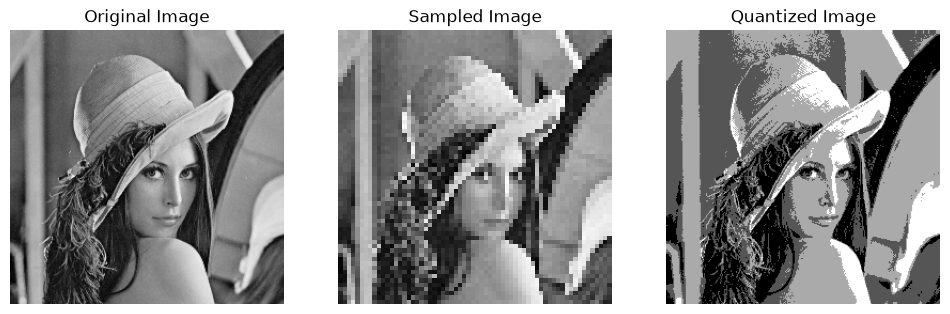

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')


plt.subplot(1, 3, 2)
plt.imshow(sampled_image, cmap='gray')
plt.title('Sampled Image')
plt.axis('off')


plt.subplot(1, 3, 3)
plt.imshow(quantized_image, cmap='gray')
plt.title('Quantized Image')
plt.axis('off')

plt.show()

In [12]:
# Task 2

img1 = Image.open(
    'lena_gray_256.tif'
).convert('L')

img2 = Image.open(
    'cameraman.tif'
).convert('L')

In [13]:
resize = (400, 400)

img1 = img1.resize(
    resize,
    Image.Resampling.LANCZOS
)

img2 = img2.resize(
    resize,
    Image.Resampling.LANCZOS
)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

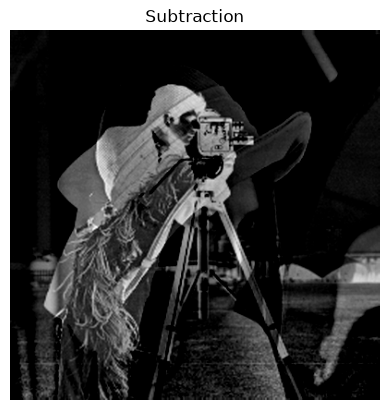

In [14]:
# 1. Subtract two images

subtraction = cv2.subtract(
    im1arr,
    im2arr
)

plt.imshow(
    subtraction,
    cmap='gray'
)

plt.title('Subtraction')
plt.axis('off')
plt.show()

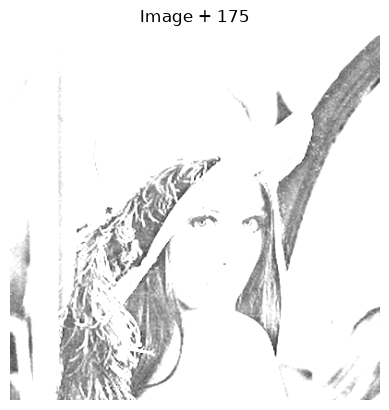

In [15]:
# 2. Add constant value 175

addition_175 = cv2.add(
    im1arr,
    175
)

plt.imshow(
    addition_175,
    cmap='gray'
)

plt.title('Image + 175')
plt.axis('off')
plt.show()

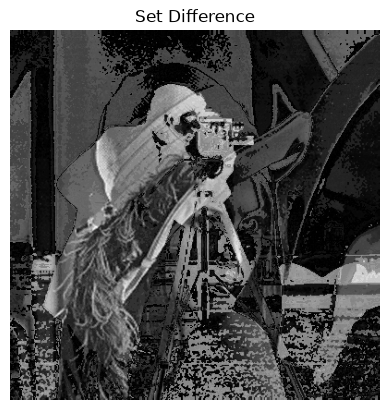

In [16]:
# 3. Set Difference

set_difference = cv2.bitwise_and(
    im1arr,
    cv2.bitwise_not(im2arr)
)

plt.imshow(
    set_difference,
    cmap='gray'
)

plt.title('Set Difference')
plt.axis('off')
plt.show()

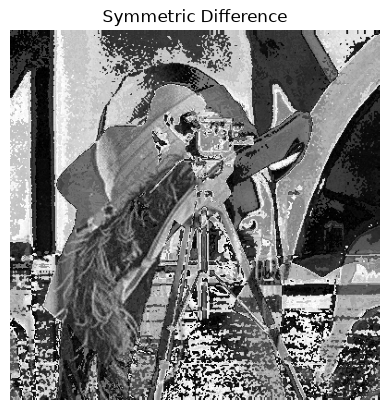

In [17]:
# 4. Symmetric Difference

symmetric_difference = cv2.bitwise_xor(
    im1arr,
    im2arr
)

plt.imshow(
    symmetric_difference,
    cmap='gray'
)

plt.title('Symmetric Difference')
plt.axis('off')
plt.show()

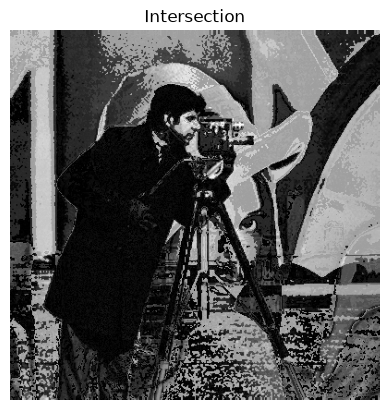

In [18]:
# 5. Intersection

intersection = cv2.bitwise_and(
    im1arr,
    im2arr
)

plt.imshow(
    intersection,
    cmap='gray'
)

plt.title('Intersection')
plt.axis('off')
plt.show()